# **Project Title**

Stock Price Prediction using Bidirectional Recurrent Neural Network (BiRNN)

# **📖 Project Overview**

This project predicts stock closing prices using a Bidirectional Recurrent Neural Network (BiRNN).
BiRNN processes time-series data in both forward and backward directions, helping the model learn better sequential patterns from historical stock prices.

You will learn:--

* Data Collection

* EDA (Exploratory Data Analysis)

* Feature Scaling

* Sequence Generation

* Building BiRNN Model

* Training & Testing

* Prediction

* Visualization

* Performance Evaluation

📂 Dataset

Use NVIDIA stock dataset from Yahoo Finance.

In [1]:
pip install yfinance tensorflow scikit-learn matplotlib pandas numpy

In [2]:
import yfinance as yf
import pandas as pd

# Download NVIDIA stock data
df = yf.download("NVDA", start="2015-01-01", end="2025-01-01")

# Save dataset
df.to_csv("nvda_stock.csv")

print(df.head())

/tmp/ipykernel_766/856124044.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("NVDA", start="2015-01-01", end="2025-01-01")
[*********************100%***********************]  1 of 1 completed

Price          Close      High       Low      Open     Volume
Ticker          NVDA      NVDA      NVDA      NVDA       NVDA
Date                                                         
2015-01-02  0.482985  0.486584  0.475308  0.482985  113680000
2015-01-05  0.474827  0.484425  0.472668  0.482985  197952000
2015-01-06  0.460432  0.476027  0.459952  0.475547  197764000
2015-01-07  0.459232  0.467870  0.457792  0.463791  321808000
2015-01-08  0.476507  0.479386  0.464270  0.464510  283780000


# **Import Libraries**

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, Bidirectional, Dropout

# **Load Dataset**

In [6]:
df = pd.read_csv("nvda_stock.csv")
df.head()



,Price,Close,High,Low,Open,Volume
0,Ticker,NVDA,NVDA,NVDA,NVDA,NVDA
1,Date,NaN,NaN,NaN,NaN,NaN
2,2015-01-02,0.48298540711402893,0.48658442933594076,0.4753075311769621,0.48298540711402893,113680000
3,2015-01-05,0.47482746839523315,0.484424809219818,0.47266808458610565,0.4829852009455686,197952000
4,2015-01-06,0.4604315459728241,0.4760271798892142,0.45995168603430814,0.47554731995069827,197764000


**Exploratory Data Analysis (EDA)**

In [7]:
df.shape

(2518, 6)

In [8]:
print(df.isnull().sum())

Price     0
Close     1
High      1
Low       1
Open      1
Volume    1
dtype: int64


**Stock Closing Price Visualization**

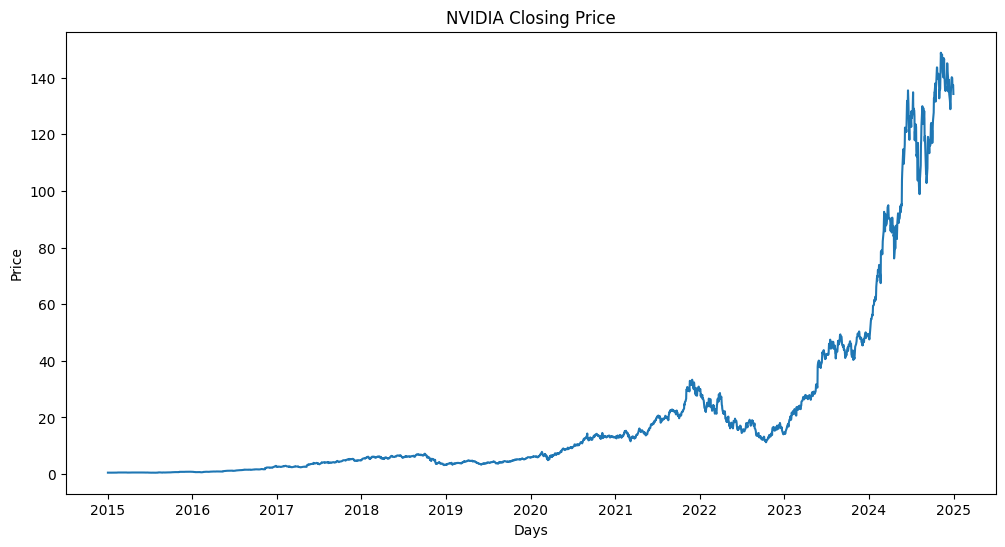

In [10]:
# 1. Drop the first two rows which contain metadata (e.g., 'Ticker', 'Date').
df = df.iloc[2:].copy()
# 2. Rename the first column (currently 'Price') to 'Date'.
df = df.rename(columns={'Price': 'Date'})
# 3. Convert 'Date' column to datetime objects and set it as the index.
df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date')
# 4. Convert relevant columns to numeric, coercing any non-numeric values to NaN.
numeric_cols = ['Close', 'High', 'Low', 'Open', 'Volume']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

plt.figure(figsize=(12,6))
plt.plot(df['Close'])
plt.title("NVIDIA Closing Price")
plt.xlabel("Days")
plt.ylabel("Price")
plt.show()

In [11]:
data = df[['Close']]

**Feature Scaling**

In [12]:
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(data)

**Create Sequences**

Using previous 60 days to predict next day.

In [13]:
X = []
y = []

time_step = 60

for i in range(time_step, len(scaled_data)):
    X.append(scaled_data[i-time_step:i, 0])
    y.append(scaled_data[i, 0])

X, y = np.array(X), np.array(y)

print(X.shape)
print(y.shape)

(2456, 60)
(2456,)


**Reshape Data for RNN**

In [14]:
X = X.reshape(X.shape[0], X.shape[1], 1)

print(X.shape)

(2456, 60, 1)


**Train Test Split**

In [15]:
split = int(0.8 * len(X))

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

print(X_train.shape)
print(X_test.shape)

(1964, 60, 1)
(492, 60, 1)


# **Build BiRNN Model**

In [16]:
model = Sequential()

model.add(Bidirectional(SimpleRNN(units=50, return_sequences=True),
                        input_shape=(X_train.shape[1],1)))

model.add(Dropout(0.2))

model.add(Bidirectional(SimpleRNN(units=50)))

model.add(Dropout(0.2))

model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


**Compile Model**

In [17]:
model.compile(optimizer='adam',
              loss='mean_squared_error')

In [18]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 60, 100)        │         5,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 100)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 100)            │        15,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,401 (79.69 KB)

 Trainable params: 20,401 (79.69 KB)

 Non-trainable params: 0 (0.00 B)

**Train Model**

Epoch 1/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - loss: 0.0021 - val_loss: 0.0672
Epoch 2/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 5s 77ms/step - loss: 0.0012 - val_loss: 0.0567
Epoch 3/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 5s 68ms/step - loss: 9.6031e-04 - val_loss: 0.0625
Epoch 4/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - loss: 8.0390e-04 - val_loss: 0.0479
Epoch 5/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 7s 81ms/step - loss: 6.3549e-04 - val_loss: 0.0408
Epoch 6/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 65ms/step - loss: 5.0436e-04 - val_loss: 0.0337
Epoch 7/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 8s 120ms/step - loss: 4.6194e-04 - val_loss: 0.0252
Epoch 8/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 6s 57ms/step - loss: 3.5839e-04 - val_loss: 0.0183
Epoch 9/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 6s 78ms/step - loss: 3.4321e-04 - val_loss: 0.0179
Epoch 10/10
62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - loss: 3.3611e-04 - val_loss: 0.0188


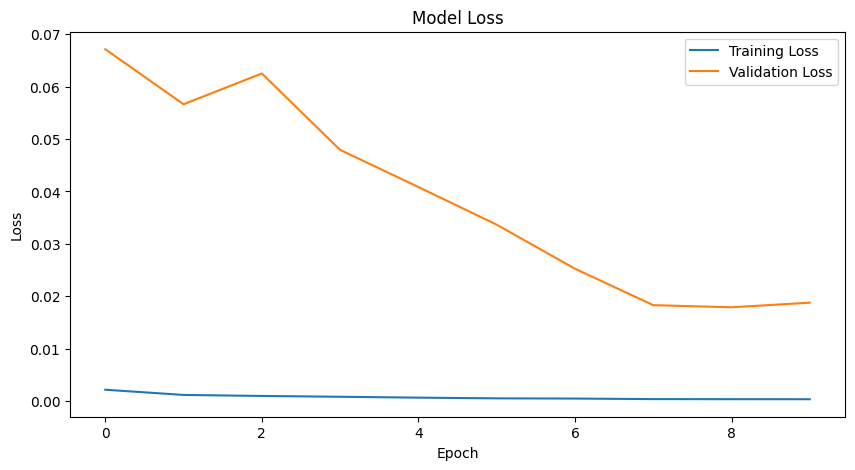

In [21]:
epochs = 10
batch_size = 32

# Train the model and store the training history
history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_data=(X_test, y_test))

plt.figure(figsize=(10,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

# **Make Predictions**

In [22]:
predictions = model.predict(X_test)

# Inverse transform
predictions = scaler.inverse_transform(predictions.reshape(-1,1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))

16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step


# **Compare Actual vs Predicted**

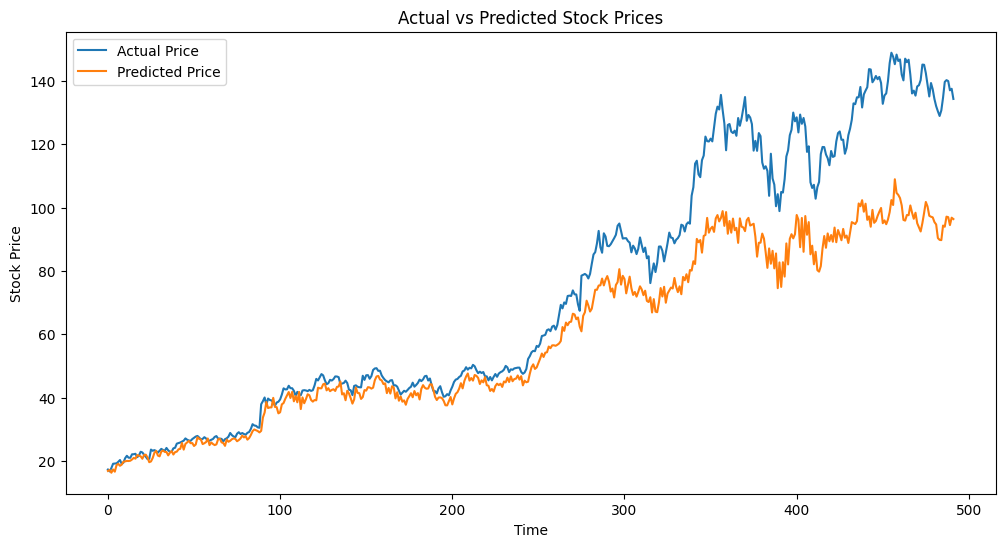

In [23]:
plt.figure(figsize=(12,6))

plt.plot(y_test_actual, label='Actual Price')
plt.plot(predictions, label='Predicted Price')

plt.title("Actual vs Predicted Stock Prices")
plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.legend()

plt.show()

**Evaluation Metrics**

In [24]:
rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))
print("RMSE:", rmse)

RMSE: 20.325549599690394


In [25]:
mae = mean_absolute_error(y_test_actual, predictions)
print("MAE:", mae)

MAE: 13.97368331847152


# **Predict Next Day Stock Price**

In [26]:
last_60_days = scaled_data[-60:]

X_input = []
X_input.append(last_60_days[:,0])

X_input = np.array(X_input)
X_input = X_input.reshape((X_input.shape[0],
                           X_input.shape[1],1))

next_day = model.predict(X_input)

next_day_price = scaler.inverse_transform(next_day)

print("Next Day Predicted Price:", next_day_price)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
Next Day Predicted Price: [[95.72196]]
